In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('sales_data_with_discounts.csv')
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [3]:
df.shape

(450, 13)

In [4]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [7]:
df.columns

Index(['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model',
       'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [9]:
num_col=df.select_dtypes(include=['int','float']).columns
num_col


Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [10]:
cat_col=df.select_dtypes(include=['object']).columns
cat_col

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

## Descriptive Analytics for Numerical Columns

In [11]:
df[num_col].describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


## statistics(Mean,Median,Mode,Standard deviation)

In [12]:
statistics=pd.DataFrame({'Mean':df[num_col].mean(),'Median':df[num_col].median(),'Mode':df[num_col].mode().iloc[0],'Standard deviation':df[num_col].std()})
statistics

,Mean,Median,Mode,Standard deviation
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


## Interpretation of these statistics

In [13]:
print("""
1.Volume:
    -Average sales quantity is not high
    -Few transcations contain is high
2.Avg price:
    -Large difference mean and median
    -Expensive products increase average price
3.Total sales:
    -High variation in sales
    -it is contribute very high
4.Discount Rate:
    -Discounts are relatively consitent products
5.Discount Amount:
    -High priced products recieve large amount
6.Net sales value:
    -Variation exists in final sales values
    """) 


1.Volume:
    -Average sales quantity is not high
    -Few transcations contain is high
2.Avg price:
    -Large difference mean and median
    -Expensive products increase average price
3.Total sales:
    -High variation in sales
    -it is contribute very high
4.Discount Rate:
    -Discounts are relatively consitent products
5.Discount Amount:
    -High priced products recieve large amount
6.Net sales value:
    -Variation exists in final sales values
    


## Data Visualization

#  Histogram

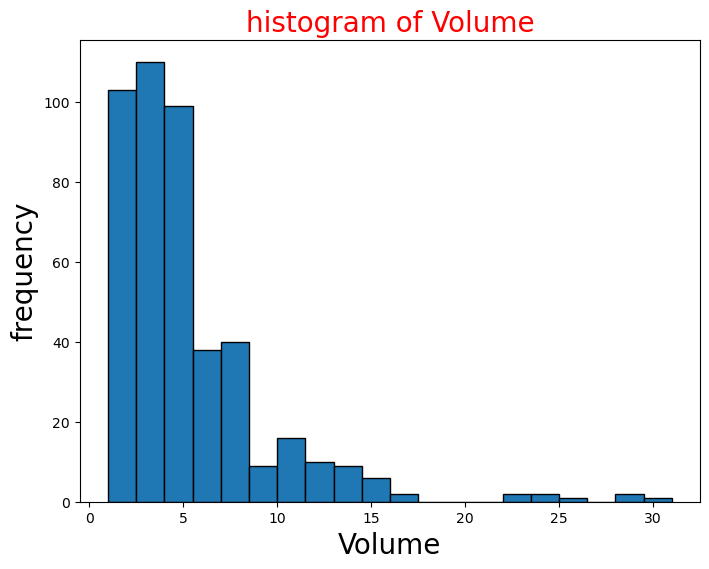

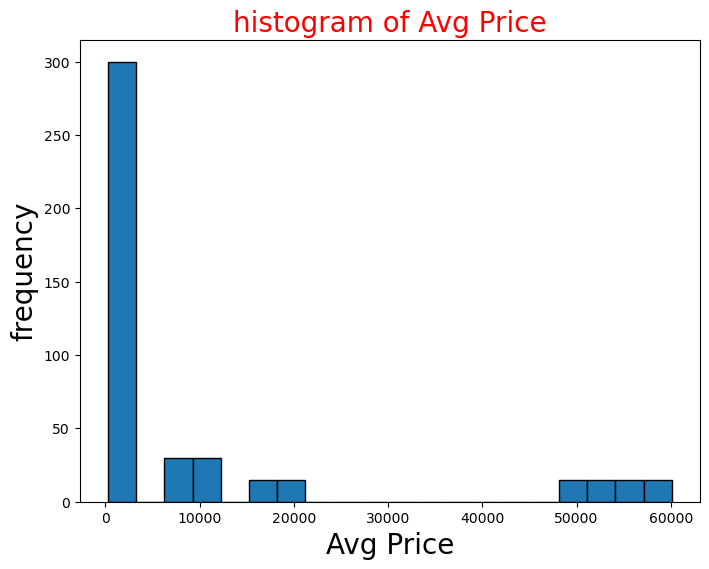

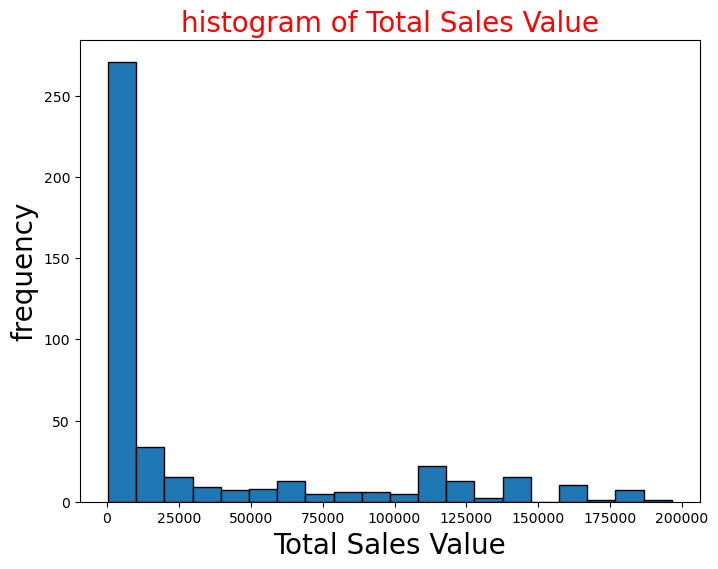

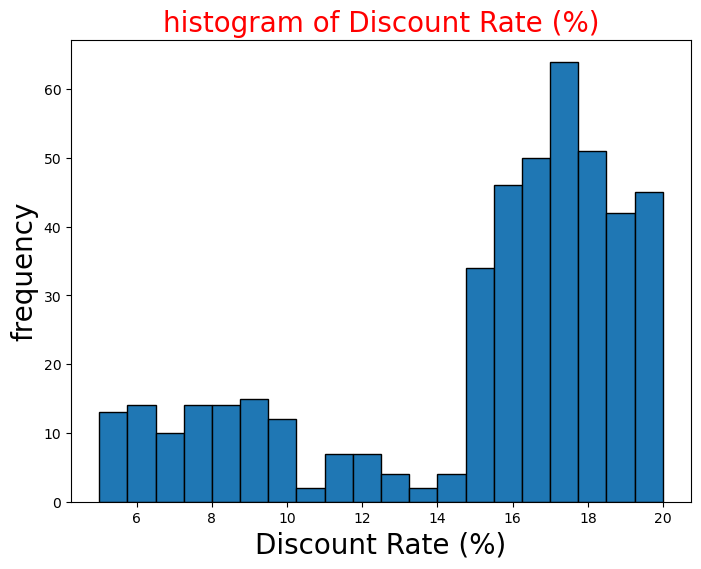

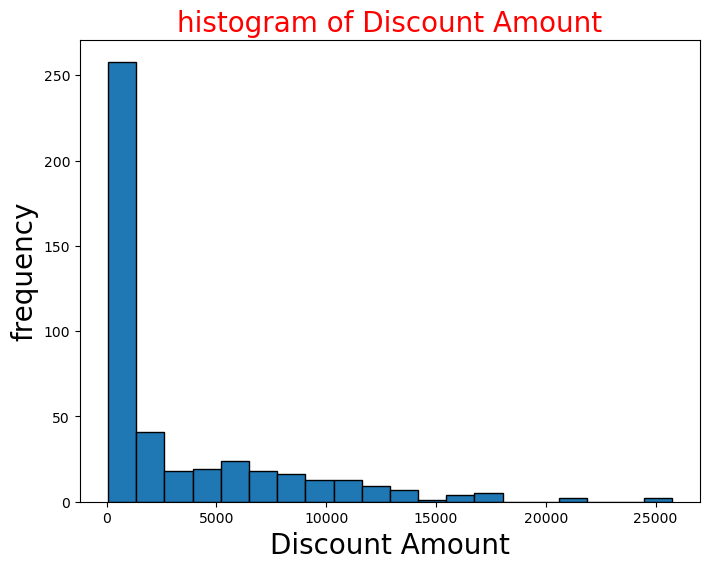

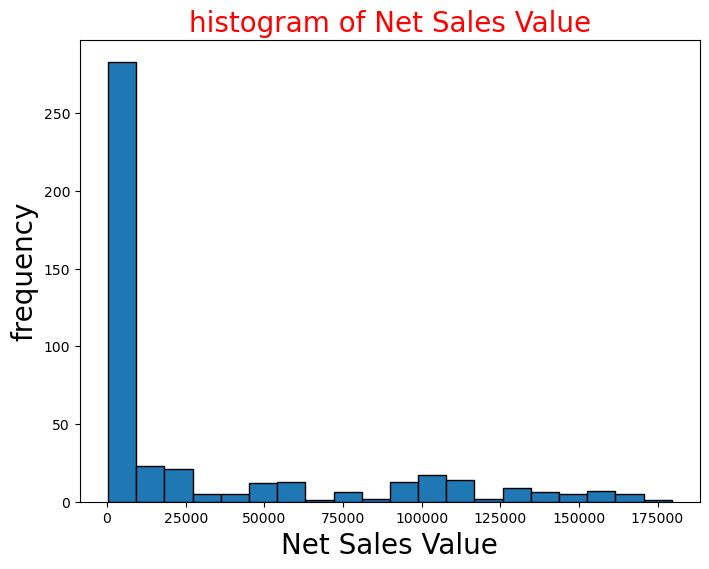

In [14]:
for column in num_col:
    plt.figure(figsize=(8,6))
    plt.hist(df[column],bins=20,edgecolor='black')
    plt.title(f'histogram of {column}',color='red',size=20)
    plt.xlabel(column,color='black',size=20)
    plt.ylabel('frequency',color='black',size=20)
    plt.show()

In [15]:
print("""
Histogram intference:
    - most numerical columns are positively skewed
    - few extreme values are present in sales and pricing columns
    - most of the columns are the lower values
""")


Histogram intference:
    - most numerical columns are positively skewed
    - few extreme values are present in sales and pricing columns
    - most of the columns are the lower values



## Boxplots

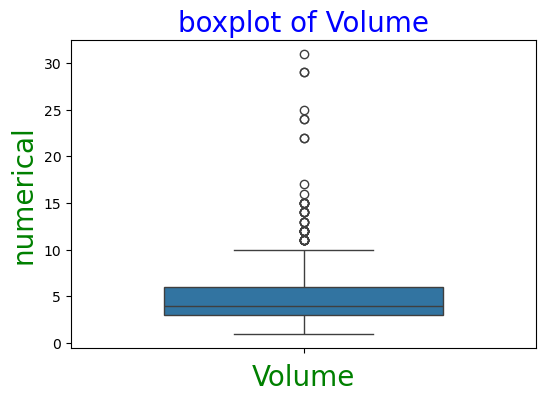

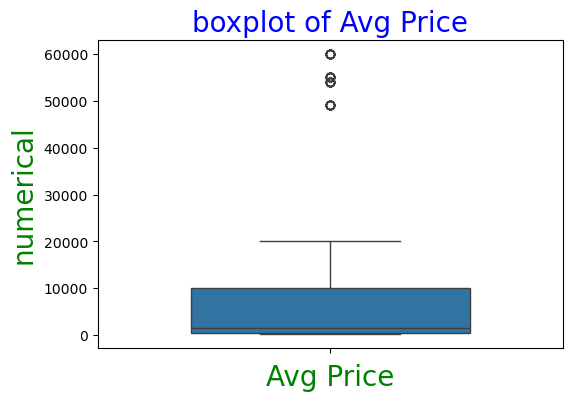

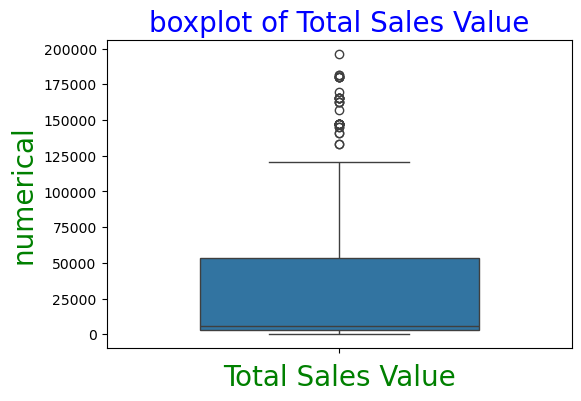

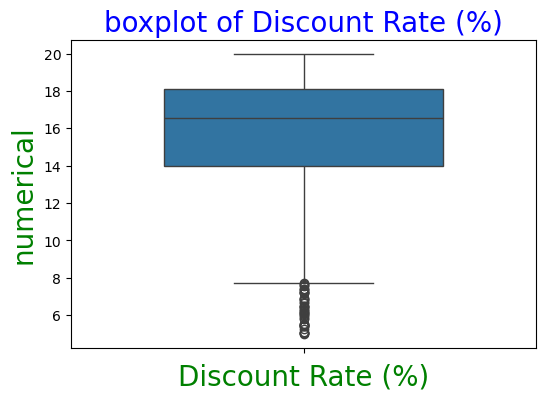

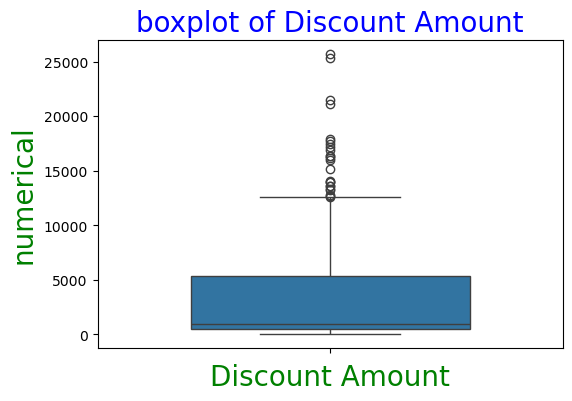

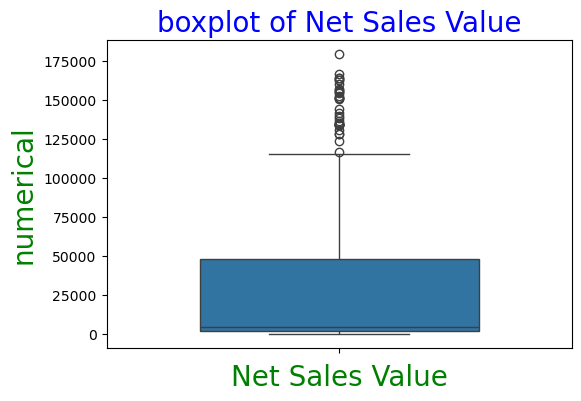

In [16]:
for i in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[i],width=0.6)
    plt.title(f'boxplot of {i}',color='blue',size='20')
    plt.xlabel(i,color='green',size='20')
    plt.ylabel('numerical',color='green',size=20)
    plt.show()

In [17]:
print("""
Boxplot inference:
    -outliers are present in Avg Price,Total Sales Value, Discount Amount, Net Sales Value
    -Extreme high value products
    -interquartile range shows variation in transcation values
""")


Boxplot inference:
    -outliers are present in Avg Price,Total Sales Value, Discount Amount, Net Sales Value
    -Extreme high value products
    -interquartile range shows variation in transcation values



## barchart

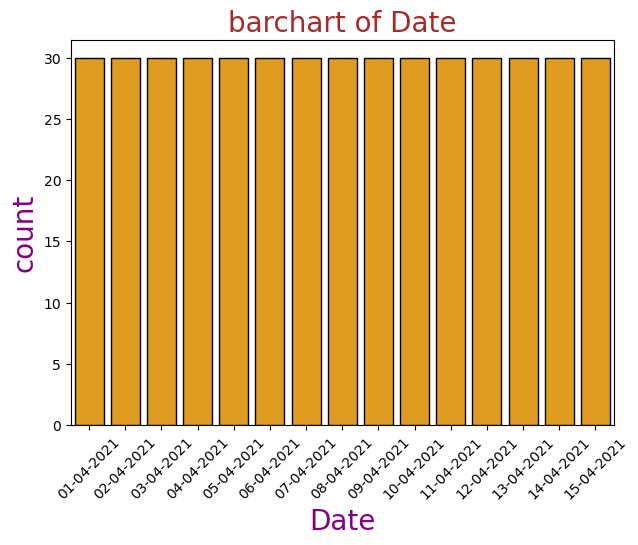

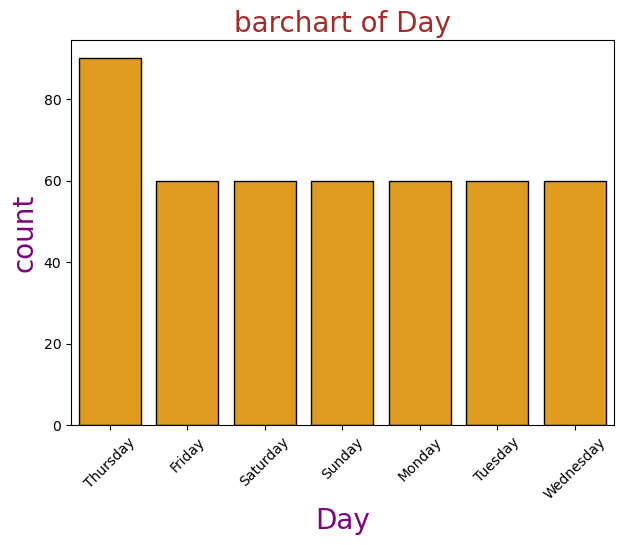

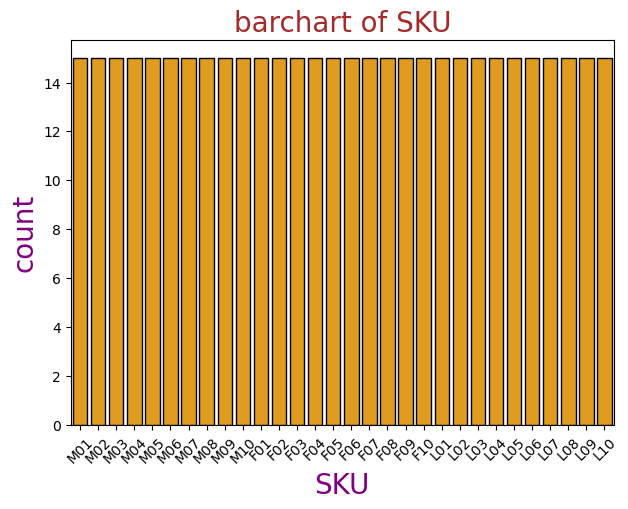

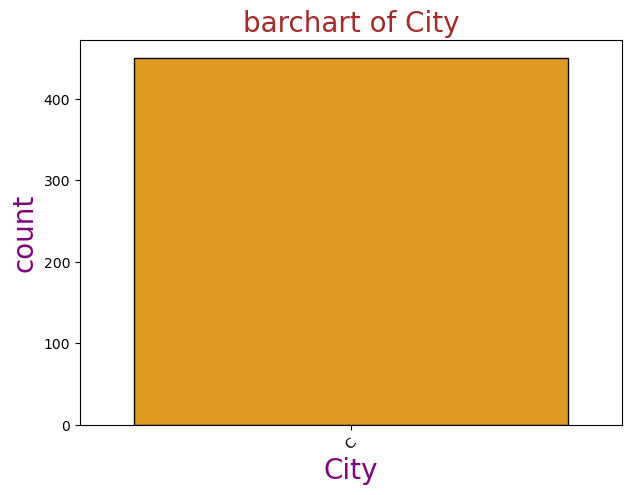

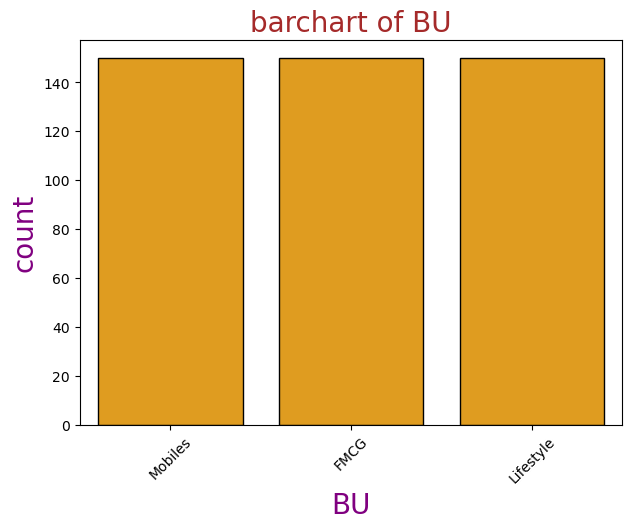

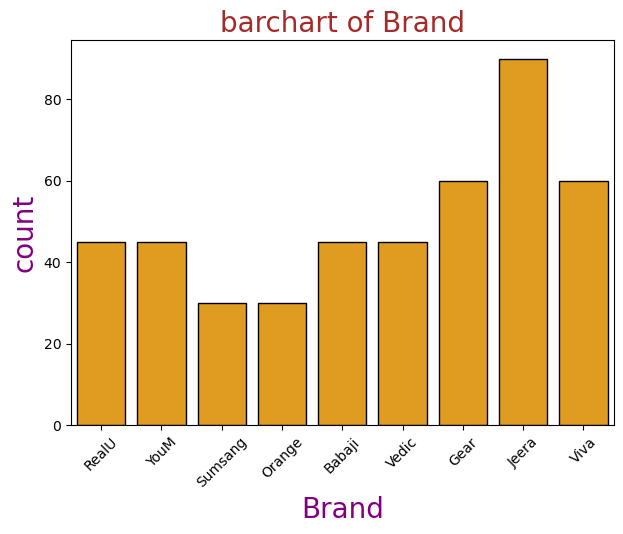

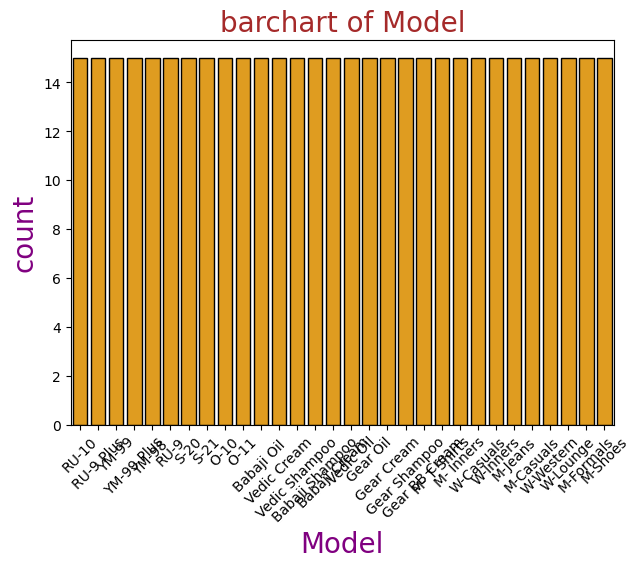

In [18]:
for col in cat_col:
    plt.figure(figsize=(7,5))
    sns.countplot(x=col,data=df,edgecolor='black',color='orange')
    plt.title(f'barchart of {col}',color='brown',size=20)
    plt.xlabel(col,color='purple',size=20)
    plt.ylabel('count',color='purple',size=20)
    plt.xticks(rotation=45)
    plt.show()

In [19]:
print("""
Bar Chart Analysis:
1. Some categories appear more frequently than others.
2. Certain brands have higher sales counts.
3. Business Units such as Mobiles and FMCG dominate the dataset.
4. Sales transactions are distributed across different cities and days.
5. Few models are sold more frequently compared to others.
Insights:
- Popular brands and models contribute more to sales.
- Business Units with higher frequency indicate strong customer demand.
- Uneven category distribution shows customer preference toward specific products.
""")


Bar Chart Analysis:
1. Some categories appear more frequently than others.
2. Certain brands have higher sales counts.
3. Business Units such as Mobiles and FMCG dominate the dataset.
4. Sales transactions are distributed across different cities and days.
5. Few models are sold more frequently compared to others.
Insights:
- Popular brands and models contribute more to sales.
- Business Units with higher frequency indicate strong customer demand.
- Uneven category distribution shows customer preference toward specific products.



## conclusion